#  APE 9: Inferencia Estadística: Pruebas de Hipótesis Paramétricas (Z y T) y Análisis del Valor-p-Grupo A

## Tarea 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp

# Parámetros del problema
mu_0 = 15.0
x_bar = 15.6
sigma = 1.2
n = 50
alpha = 0.05

# 1. Cálculo del estadístico Z de prueba
Z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))

# 2. Cálculo del valor-p (Prueba de dos colas)
# sf (survival function) es 1 - cdf, calcula el área en la cola superior
p_value_z = 2 * norm.sf(np.abs(Z_calc))

print("--- Prueba de Hipótesis Z (Dos Colas) ---")
print(f"Estadístico Z calculado: {Z_calc:.4f}")
print(f"Valor-p: {p_value_z:.4e}")

if p_value_z < alpha:
  print("Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.")
else:
  print("Conclusión: NO se rechaza H0. No hay evidencia suficiente para refutar al fabricante.")


--- Prueba de Hipótesis Z (Dos Colas) ---
Estadístico Z calculado: 3.5355
Valor-p: 4.0695e-04
Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.


## Tarea 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp

# Muestra empírica pequeña (n=8)
tiempos_carga = [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]
mu_meta = 2.6
alpha_t = 0.05

# Ejecución de la prueba T de una muestra (Prueba de una cola: H1: mu > 2.6)
# ttest_1samp devuelve p-value de 2 colas por defecto.
# Para cola superior (greater), p-value de 1 cola en SciPy moderno se especifica con alternative='greater'
stat_t, p_value_t = ttest_1samp(tiempos_carga, popmean=mu_meta, alternative='greater')

print(f"--- Prueba de Hipótesis T (Cola Superior) ---")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p (1 cola): {p_value_t:.4f}")

if p_value_t < alpha_t:
  print("Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).")
else:
  print("NO se rechaza H0. El tiempo de carga estadísticamente cumple la meta.")


--- Prueba de Hipótesis T (Cola Superior) ---
Estadístico T: 2.9055
Valor-p (1 cola): 0.0114
Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6s (Incumple la meta).


## Tarea 3

In [ ]:
import pandas as pd
from scipy import stats

nombres_columnas = ["Fecha", "Tipo", "Emisor", "Cantidad", "Valor_Nominal",
                    "Precio", "Valor_Nominal_Total", "Monto_Efectivo",
                    "Casa_Origen", "Casa_Destino", "Bolsa"]

df_regional = pd.read_csv("BVG_Acciones_export.csv", names=nombres_columnas, skiprows=1)

# Uso de "Precio"
df_regional['Precio'] = pd.to_numeric(df_regional['Precio'], errors='coerce')
datos_reales = df_regional['Precio'].dropna()

print("Afirmación: El precio promedio histórico de las acciones en el mercado regional es de $2.50 USD")
print("Parámetro: μ0 =2.50")


# Aplicación de la Prueba T de una muestra
mu_0 = 2.50
t_stat, p_value = stats.ttest_1samp(datos_reales, mu_0, alternative='two-sided')

print(f"Estadístico T: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Afirmación: El precio promedio histórico de las acciones en el mercado regional es de $2.50 USD
Parámetro: μ0 =2.50
Estadístico T: 28.4493
Valor p: 0.0000


### El valor -p es 0, esto por el hecho de que dentro del dataset, hay valores atipicos dentro de la variable "Precio". Esto genera que sea imposible decir que el precio promedio historico en el mercado regional es de 2.50 USD. Revelando una alta segmentación y volatilidad de los precios que se manejan en el mercado. Por lo que no hay un precio promedio seguro que se pueda usar para tomar desiciones fiables.

## Tarea 4

n =     10 --> Media = 4.69890 --> Z = -0.9522 --> p = 0.34101417
n =    100 --> Media = 5.00038 --> Z = 0.0038 --> p = 0.99693230
n =   1000 --> Media = 4.95142 --> Z = -1.5363 --> p = 0.12445647
n =  10000 --> Media = 5.01370 --> Z = 1.3702 --> p = 0.17062397
n = 100000 --> Media = 5.01121 --> Z = 3.5447 --> p = 0.00039312


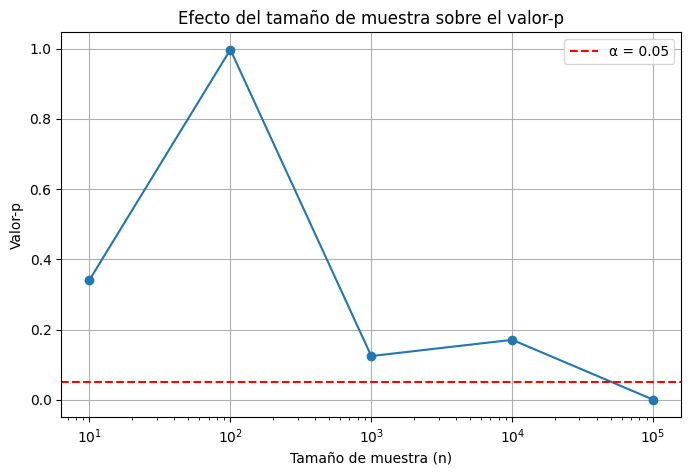

In [ ]:
np.random.seed(42)

mu_real = 5.01
sigma = 1.0

# Población grande simulada
poblacion = np.random.normal(mu_real, sigma, 1000000)

# Hipótesis nula
mu_0 = 5.00

# Tamaños de muestra
n_list = [10, 100, 1000, 10000, 100000]

p_values = []

for n in n_list:
    muestra = np.random.choice(poblacion, size=n, replace=False)
    x_bar = np.mean(muestra)
    # Estadístico Z
    z = (x_bar - mu_0) / (sigma / np.sqrt(n))

    # Valor-p (dos colas)
    p_value = 2 * norm.sf(abs(z))

    p_values.append(p_value)

    print(f"n = {n:6d} --> Media = {x_bar:.5f} --> Z = {z:.4f} --> p = {p_value:.8f}")


plt.figure(figsize=(8,5))

plt.plot(n_list, p_values, marker='o')

plt.xscale('log')

plt.axhline(
    y=0.05,
    color='red',
    linestyle='--',
    label='α = 0.05'
)

plt.xlabel('Tamaño de muestra (n)')
plt.ylabel('Valor-p')
plt.title('Efecto del tamaño de muestra sobre el valor-p')

plt.legend()
plt.grid(True)

plt.show()

###Cuando n crece masivamente, el valor-p tiende a disminuir, incluso si la diferencia real entre la media observada y la hipótesis nula es muy pequeña o prácticamente irrelevante.

###Esto ocurre porque al aumentar el tamaño de la muestra, el error estándar se reduce, haciendo que la prueba estadística sea capaz de detectar diferencias cada vez más pequeñas. Como consecuencia, una diferencia mínima, como 0.01 V, puede producir valores-p extremadamente bajos y llevar al rechazo de la hipótesis nula.



## Preguntas de control

### **1.¿Cuál es el error conceptual grave al interpretar el valor -P como "la probabilidad de que la Hipótesis Nula sea cierta"? Defina correctamente el valor -P.**
#### El valor -p no mide la probabilidad de la hipótesis, sino la probabilidad de los datos y cómo estos desmienten o no a H0. Normalmente en estadística, la Hipótesis Nula (Hn) es fija, es decir no puede ser cierta o falsa, por lo que no tiene una probabilidad de ocurrir. La realidad es que el valor -p es una probabilidad condicionada a que la hipótesis nula sea cierta, que no haya efecto. El valor -p es la probabilidad de obtener un resultado observado (o uno aún más extremo), asumiendo como premisa absoluta que la Hipótesis Nula (Hn) es verdadera.
#### En términos prácticos, es una medida de la compatibilidad entre los datos obtenidos y la hipótesis nula: un valor -p muy bajo indica que los datos observados son extremadamente inusuales bajo el supuesto de que Hn sea cierta, lo que da motivos para rechazarla.



### **2.En el contexto de la Tarea 3 (Dataset Regional), describa en lenguaje no estadístico qué representaría cometer un Error Tipo I y un Error Tipo II en su toma de decisiones.**

#### Dar paso a un Error Tipo I significa que, se está asegurando que el precio promedio de acciones en el mercado es 2.50 USD y ha cambiado y, por lo tanto, hay que tomar decisiones diferentes a las que se venían tomando respecto al mercado. Pero eso es falso, y se toman acciones innecesariamente.

#### Por otro lado, un Error Tipo II significa que, se está asegurando que el precio promedio de acciones del mercado no ha cambiado. Por lo que se siguen tomando las mismas consideraciones que antes, cuando en realidad el mercado está cambiando y hace falta un nuevo análisis, para determinar si la situación es peligrosa para nosotros.

### **3.Si en su análisis regional la prueba arroja un p=0.051 y su a=0.05, estadísticamente NO rechaza H0 . Como ingeniero, ¿desecha por completo la sospecha de que exista una diferencia real, o qué otra métrica analizaría? (Pista: Relacione esto con la Semana 9).**
#### ¿Se desecha?
#### No, técnicamente, no se debería rechazar la posibilidad de un cambio real, pero se deberían analizar otras métricas para validar si realmente hay diferencia o no. Pues tomar una decisión drástica basada solo en una milésima sería un gran error, ya que podría existir una diferencia real que la prueba no pudo confirmar debido a una muestra pequeña, por ejemplo.
#### ¿Qué otra métrica utilizar?
#### Usamos el Tamaño del Efecto, ya que dice si el cambio que se detectó es grande o indiferente, permitiendo decidir si vale la pena invertir dinero o tiempo en esa sospecha regional. También podría usarse el IC, para ver si el valor de H0 está dentro de él, lo que impediría descartar la posibilidad de una diferencia real. O por último, se podría engrandecer la muestra para verificar si el valor -p se estabiliza y muestra un resultado más claro.

### **4.Explique la conclusión de su investigación en la Tarea 4 (ABI). ¿Por qué en el "Big Data" las pruebas de hipótesis clásicas tienden a rechazar H0 casi siempre?**
#### En el Big Data, al contar con un tamaño de muestras muy grande, se encoge el error estándar. Esto hace que, tanto en Z como en T, al dividir la diferencia observada entre este error estándar tan pequeño, se arroje un valor gigantesco y el -p sea cercano a 0. Esto ocurre porque, al ser el valor de Z o T tan grande, se tiende al infinito y se recorre prácticamente toda la función; por lo tanto, la probabilidad y el área bajo la curva de la cola se vuelven cero, ya que el valor-p es el residuo matemático, el de la cola, que falta para alcanzar el 100% de una función acumulada. Entonces, el sistema se vuelve tan sensible al ruido que cualquier mínima diferencia observada la toma en cuenta, aun si no es significativa, por lo que rechaza H0, incluso cuando esa diferencia insignificante no es algo de lo que preocuparse. Ningún H0 es exacto, siempre habrá ruido, por lo que trabajar con Big Data genera un problema al considerar todo como significativo, ahí es donde entra el criterio del ingeniero para saber si lo que se muestra en la teoría es realmente necesario en la práctica.



### **5.Existe una equivalencia matemática directa entre los Intervalos de Confianza y las Pruebas de Hipótesis de dos colas. Si un I C del 95% para u no incluye a u0, ¿qué le sucederá inevitablemente al valor -p si evalúa H0: u=u0 con a = 0.05?**
#### Si el Intervalo de Confianza (IC) del 95% no incluye el valor u0,  el valor -p será menor a 0.05 (p < 0.05). El IC del 95% representa el conjunto de todos los valores de u0 para los cuales no se rechazaría la hipótesis nula. Si un valor queda fuera de este rango, automáticamente se rechaza H0. Un a = 0.05 define el mismo umbral de error que un nivel de confianza del 95% (1 - a) . Si el valor nulo es tan distante de la estimación muestral que el intervalo no alcanza a incluirlo, entonces la probabilidad de obtener un resultado igual o más extremo (valor -P) es, por definición, menor al 5% de tolerancia.




